# Telemetry Merge + Clean High-RPM Trip Plots

This notebook:
- merges multiple CSV/XLSX files with the same columns
- sorts by `Timestamp`
- segments trips when the timestamp gap is greater than **5 minutes**
- filters to only plot points where **Motor Speed (RPM) > 1500**
- creates cleaner **day-wise, trip-wise** graphs

Expected columns:
- `Timestamp`
- `Battery Current (A)`
- `Motor Speed (RPM)`
- `Motor AC Current (A)`


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)


## 1) Set input files

Add the full paths of your files below. They can have the same filename if they are in different folders.

In [7]:
file_paths = [
    r"/Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-04/vehicle_id=EV01.csv",
    r"/Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-08/vehicle_id=EV01.csv",
    r"/Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-10/vehicle_id=EV01.csv",
]

# Where outputs will be written
output_dir = Path('telemetry_output')
output_dir.mkdir(exist_ok=True)

# Trip gap threshold in minutes
trip_gap_minutes = 5

# RPM threshold to highlight
rpm_threshold = 1500


## Optional file picker

Uncomment this cell if you want to choose files from a file browser.

In [8]:
# import tkinter as tk
# from tkinter import filedialog
#
# root = tk.Tk()
# root.withdraw()
# selected = filedialog.askopenfilenames(
#     title='Select telemetry files',
#     filetypes=[('Data files', '*.csv *.xlsx *.xls'), ('All files', '*.*')]
# )
# file_paths = list(selected)
# print(file_paths)


## 2) Load and merge files

In [9]:
required_columns = [
    'Timestamp',
    'Battery Current (A)',
    'Motor Speed (RPM)',
    'Motor AC Current (A)'
]

def read_data_file(path):
    path = Path(path)
    suffix = path.suffix.lower()
    
    if suffix == '.csv':
        df = pd.read_csv(path)
    elif suffix in ['.xlsx', '.xls']:
        df = pd.read_excel(path)
    else:
        raise ValueError(f'Unsupported file type: {path}')
    
    df.columns = [str(c).strip() for c in df.columns]
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f'{path} is missing columns: {missing}')
    
    df = df[required_columns].copy()
    df['Source File'] = str(path)
    return df

if not file_paths:
    raise ValueError('Please add file paths in file_paths or use the file picker cell.')

frames = []
for fp in file_paths:
    part = read_data_file(fp)
    frames.append(part)
    print(f'Loaded {fp} -> {len(part):,} rows')

df = pd.concat(frames, ignore_index=True)
print(f'\nMerged rows: {len(df):,}')
df.head()

Loaded /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-04/vehicle_id=EV01.csv -> 74,910 rows
Loaded /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-08/vehicle_id=EV01.csv -> 110,489 rows
Loaded /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-03-10/vehicle_id=EV01.csv -> 10,642 rows

Merged rows: 196,041


,Timestamp,Battery Current (A),Motor Speed (RPM),Motor AC Current (A),Source File
0,"02/03/2026, 24:00:00",10.0,872.0,10.0,/Users/rhythmparashar/Desktop/ev-predictive-an...
1,"02/03/2026, 24:00:02",10.0,872.0,10.0,/Users/rhythmparashar/Desktop/ev-predictive-an...
2,"02/03/2026, 24:00:04",10.0,871.0,10.0,/Users/rhythmparashar/Desktop/ev-predictive-an...
3,"02/03/2026, 24:00:06",11.0,869.0,10.0,/Users/rhythmparashar/Desktop/ev-predictive-an...
4,"02/03/2026, 24:00:08",10.0,873.0,10.0,/Users/rhythmparashar/Desktop/ev-predictive-an...


## 3) Parse timestamps, clean, sort, and segment trips

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

for col in ['Battery Current (A)', 'Motor Speed (RPM)', 'Motor AC Current (A)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

before_drop = len(df)
df = df.dropna(subset=required_columns).copy()
after_drop = len(df)
print(f'Dropped {before_drop - after_drop:,} invalid rows')

df = df.sort_values('Timestamp').reset_index(drop=True)
df['Time Gap'] = df['Timestamp'].diff()
gap_threshold = pd.Timedelta(minutes=trip_gap_minutes)
df['New Trip Flag'] = df['Time Gap'].isna() | (df['Time Gap'] > gap_threshold)
df['Trip ID Global'] = df['New Trip Flag'].cumsum().astype(int)
df['Date'] = df['Timestamp'].dt.date

trip_map = (
    df[['Date', 'Trip ID Global']]
    .drop_duplicates()
    .sort_values(['Date', 'Trip ID Global'])
    .assign(Trip_No=lambda x: x.groupby('Date').cumcount() + 1)
)

df = df.merge(trip_map, on=['Date', 'Trip ID Global'], how='left')
df['High RPM'] = df['Motor Speed (RPM)'] > rpm_threshold

df.head()

Dropped 62,346 invalid rows


,Timestamp,Battery Current (A),Motor Speed (RPM),Motor AC Current (A),Source File,Time Gap,New Trip Flag,Trip ID Global,Date,Trip_No,High RPM
0,2026-02-03 03:38:40,14.0,820.0,15.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,NaT,True,1,2026-02-03,1,False
1,2026-02-03 03:38:42,12.0,871.0,15.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,False
2,2026-02-03 03:38:44,12.0,881.0,15.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,False
3,2026-02-03 03:38:46,12.0,882.0,13.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,False
4,2026-02-03 03:38:48,14.0,903.0,15.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,False


## 4) Save merged data

In [11]:
merged_csv = output_dir / 'merged_sorted_trip_segmented.csv'
df.to_csv(merged_csv, index=False)
print(f'Saved merged file: {merged_csv.resolve()}')

Saved merged file: /Users/rhythmparashar/Desktop/ev-predictive-analytics/telemetry_output/merged_sorted_trip_segmented.csv


## 5) Create a trip summary

In [12]:
trip_summary = (
    df.groupby(['Date', 'Trip_No', 'Trip ID Global'], as_index=False)
      .agg(
          Start_Time=('Timestamp', 'min'),
          End_Time=('Timestamp', 'max'),
          Points=('Timestamp', 'size'),
          High_RPM_Points=('High RPM', 'sum'),
          Max_RPM=('Motor Speed (RPM)', 'max')
      )
      .sort_values(['Date', 'Trip_No'])
)

trip_summary['Has_High_RPM'] = trip_summary['High_RPM_Points'] > 0

trip_summary_csv = output_dir / 'trip_summary.csv'
trip_summary.to_csv(trip_summary_csv, index=False)
print(f'Saved trip summary: {trip_summary_csv.resolve()}')
trip_summary.head(20)

Saved trip summary: /Users/rhythmparashar/Desktop/ev-predictive-analytics/telemetry_output/trip_summary.csv


,Date,Trip_No,Trip ID Global,Start_Time,End_Time,Points,High_RPM_Points,Max_RPM,Has_High_RPM
0,2026-02-03,1,1,2026-02-03 03:38:40,2026-02-03 03:43:22,140,66,1985.0,True
1,2026-02-03,2,2,2026-02-03 03:51:16,2026-02-03 06:29:07,4570,889,2076.0,True
2,2026-02-03,3,3,2026-02-03 06:54:16,2026-02-03 07:19:58,766,255,2118.0,True
3,2026-02-03,4,4,2026-02-03 10:04:31,2026-02-03 11:11:34,1992,939,2352.0,True
4,2026-02-03,5,5,2026-02-03 11:50:21,2026-02-03 12:47:57,1704,667,2182.0,True
5,2026-02-03,6,6,2026-02-03 14:43:15,2026-02-03 15:50:11,1998,697,2227.0,True
6,2026-02-03,7,7,2026-02-03 17:29:49,2026-02-03 17:49:18,201,13,2048.0,True
7,2026-02-03,8,8,2026-02-03 17:55:09,2026-02-03 17:55:09,1,0,870.0,False
8,2026-02-03,9,9,2026-02-03 18:11:21,2026-02-03 19:51:58,2916,607,2264.0,True
9,2026-02-03,10,10,2026-02-03 21:37:26,2026-02-03 22:46:50,2048,269,2124.0,True


## 6) Keep only points above the RPM threshold for plotting

This is the main cleanup step.

In [13]:
df_high = df[df['Motor Speed (RPM)'] > rpm_threshold].copy()
print(f'Rows above {rpm_threshold} RPM: {len(df_high):,} / {len(df):,}')
df_high.head()

Rows above 1500 RPM: 30,411 / 133,695


,Timestamp,Battery Current (A),Motor Speed (RPM),Motor AC Current (A),Source File,Time Gap,New Trip Flag,Trip ID Global,Date,Trip_No,High RPM
11,2026-02-03 03:39:03,12.0,1678.0,65.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,True
13,2026-02-03 03:39:07,24.0,1830.0,16.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,True
14,2026-02-03 03:39:09,64.0,1772.0,16.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,True
15,2026-02-03 03:39:11,18.0,1800.0,53.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,True
16,2026-02-03 03:39:13,53.0,1905.0,53.0,/Users/rhythmparashar/Desktop/ev-predictive-an...,0 days 00:00:02,False,1,2026-02-03,1,True


## 7) Plot helpers

In [14]:
def safe_name(text):
    return ''.join(c if c.isalnum() or c in '-_ ' else '_' for c in str(text)).strip().replace(' ', '_')

def plot_high_rpm_trip(trip_df, x_col, out_file, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    t_num = trip_df['Timestamp'].astype('int64') / 1e9
    scatter = ax.scatter(
        trip_df[x_col],
        trip_df['Motor Speed (RPM)'],
        c=t_num,
        cmap='viridis',
        s=12,
        alpha=0.75
    )
    
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Timestamp')
    tick_locs = np.linspace(t_num.min(), t_num.max(), min(5, len(trip_df)))
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels(pd.to_datetime(tick_locs, unit='s').strftime('%H:%M:%S'))
    
    start_ts = trip_df['Timestamp'].min()
    end_ts = trip_df['Timestamp'].max()
    
    ax.set_xlabel(x_col)
    ax.set_ylabel('Motor Speed (RPM)')
    ax.set_title(title + f'\nFiltered: RPM > {rpm_threshold} | {start_ts:%Y-%m-%d %H:%M:%S} to {end_ts:%H:%M:%S}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_file, bbox_inches='tight')
    plt.close(fig)


## 8) Generate clean plots only for trips containing RPM > threshold

In [15]:
plots_dir = output_dir / 'plots_high_rpm_only'
plots_dir.mkdir(exist_ok=True)

created_files = []

for (date_value, trip_no), trip_df in df_high.groupby(['Date', 'Trip_No'], sort=True):
    trip_df = trip_df.sort_values('Timestamp').copy()
    if trip_df.empty:
        continue

    day_dir = plots_dir / safe_name(date_value)
    day_dir.mkdir(exist_ok=True)

    file1 = day_dir / f'trip_{trip_no:03d}_rpm_vs_motor_ac_current_high_rpm.png'
    file2 = day_dir / f'trip_{trip_no:03d}_rpm_vs_battery_current_high_rpm.png'

    plot_high_rpm_trip(
        trip_df=trip_df,
        x_col='Motor AC Current (A)',
        out_file=file1,
        title=f'Date {date_value} | Trip {trip_no} | RPM vs Motor AC Current'
    )

    plot_high_rpm_trip(
        trip_df=trip_df,
        x_col='Battery Current (A)',
        out_file=file2,
        title=f'Date {date_value} | Trip {trip_no} | RPM vs Battery Current'
    )

    created_files.extend([file1, file2])

print(f'Created {len(created_files)} clean plot files')
print(f'Plots folder: {plots_dir.resolve()}')

Created 152 clean plot files
Plots folder: /Users/rhythmparashar/Desktop/ev-predictive-analytics/telemetry_output/plots_high_rpm_only


## 9) Optional: combined all-trip clean plots

These plots combine all high-RPM points from all files into one figure.

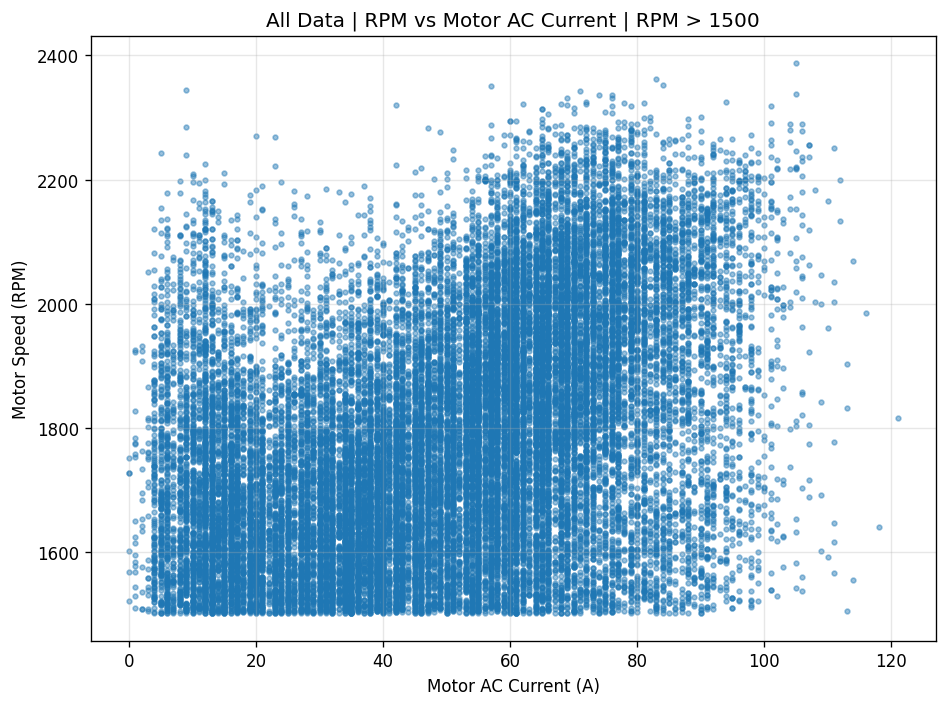

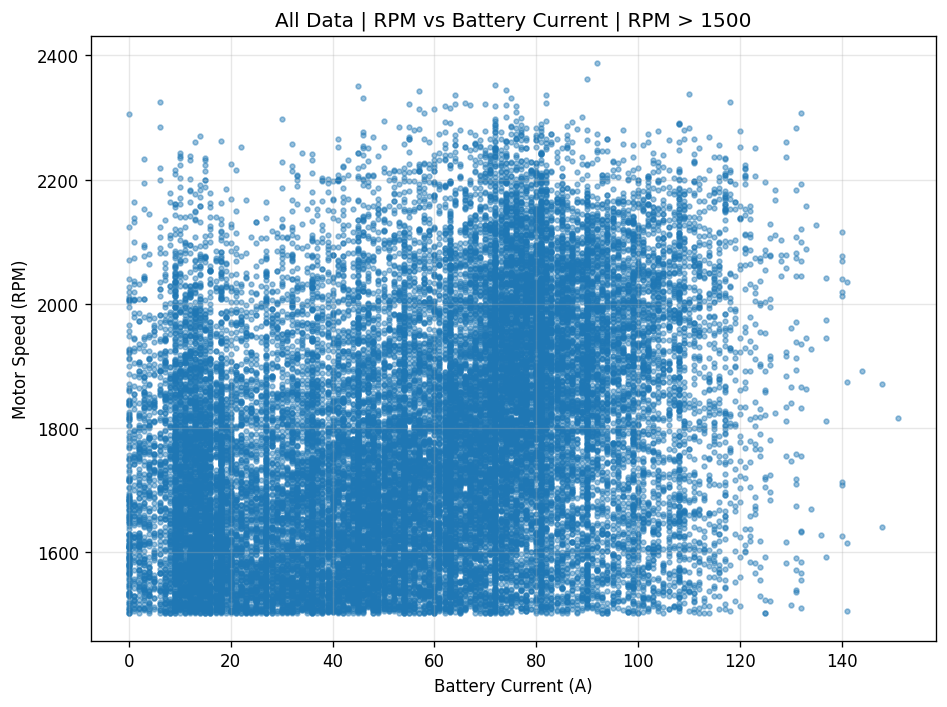

In [16]:
if not df_high.empty:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_high['Motor AC Current (A)'], df_high['Motor Speed (RPM)'], s=8, alpha=0.45)
    plt.xlabel('Motor AC Current (A)')
    plt.ylabel('Motor Speed (RPM)')
    plt.title(f'All Data | RPM vs Motor AC Current | RPM > {rpm_threshold}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'all_data_rpm_vs_motor_ac_current_high_rpm.png', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(df_high['Battery Current (A)'], df_high['Motor Speed (RPM)'], s=8, alpha=0.45)
    plt.xlabel('Battery Current (A)')
    plt.ylabel('Motor Speed (RPM)')
    plt.title(f'All Data | RPM vs Battery Current | RPM > {rpm_threshold}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'all_data_rpm_vs_battery_current_high_rpm.png', bbox_inches='tight')
    plt.show()
else:
    print(f'No points found above {rpm_threshold} RPM.')


## 10) Preview results

In [17]:
display(trip_summary.head(20))
print('\nTrips with high RPM points:')
display(trip_summary[trip_summary['Has_High_RPM']].head(20))

,Date,Trip_No,Trip ID Global,Start_Time,End_Time,Points,High_RPM_Points,Max_RPM,Has_High_RPM
0,2026-02-03,1,1,2026-02-03 03:38:40,2026-02-03 03:43:22,140,66,1985.0,True
1,2026-02-03,2,2,2026-02-03 03:51:16,2026-02-03 06:29:07,4570,889,2076.0,True
2,2026-02-03,3,3,2026-02-03 06:54:16,2026-02-03 07:19:58,766,255,2118.0,True
3,2026-02-03,4,4,2026-02-03 10:04:31,2026-02-03 11:11:34,1992,939,2352.0,True
4,2026-02-03,5,5,2026-02-03 11:50:21,2026-02-03 12:47:57,1704,667,2182.0,True
5,2026-02-03,6,6,2026-02-03 14:43:15,2026-02-03 15:50:11,1998,697,2227.0,True
6,2026-02-03,7,7,2026-02-03 17:29:49,2026-02-03 17:49:18,201,13,2048.0,True
7,2026-02-03,8,8,2026-02-03 17:55:09,2026-02-03 17:55:09,1,0,870.0,False
8,2026-02-03,9,9,2026-02-03 18:11:21,2026-02-03 19:51:58,2916,607,2264.0,True
9,2026-02-03,10,10,2026-02-03 21:37:26,2026-02-03 22:46:50,2048,269,2124.0,True



Trips with high RPM points:


,Date,Trip_No,Trip ID Global,Start_Time,End_Time,Points,High_RPM_Points,Max_RPM,Has_High_RPM
0,2026-02-03,1,1,2026-02-03 03:38:40,2026-02-03 03:43:22,140,66,1985.0,True
1,2026-02-03,2,2,2026-02-03 03:51:16,2026-02-03 06:29:07,4570,889,2076.0,True
2,2026-02-03,3,3,2026-02-03 06:54:16,2026-02-03 07:19:58,766,255,2118.0,True
3,2026-02-03,4,4,2026-02-03 10:04:31,2026-02-03 11:11:34,1992,939,2352.0,True
4,2026-02-03,5,5,2026-02-03 11:50:21,2026-02-03 12:47:57,1704,667,2182.0,True
5,2026-02-03,6,6,2026-02-03 14:43:15,2026-02-03 15:50:11,1998,697,2227.0,True
6,2026-02-03,7,7,2026-02-03 17:29:49,2026-02-03 17:49:18,201,13,2048.0,True
8,2026-02-03,9,9,2026-02-03 18:11:21,2026-02-03 19:51:58,2916,607,2264.0,True
9,2026-02-03,10,10,2026-02-03 21:37:26,2026-02-03 22:46:50,2048,269,2124.0,True
11,2026-03-03,1,12,2026-03-03 01:00:01,2026-03-03 02:11:28,1992,221,2137.0,True


## Notes

- This version only plots points where `Motor Speed (RPM) > 1500`.
- That usually makes the plots much easier to understand.
- You can change the threshold by editing `rpm_threshold`.
- You still get the fully merged dataset and the trip summary CSV.


In [18]:
from matplotlib.backends.backend_pdf import PdfPages
import math

report_pdf = output_dir / "telemetry_trip_report.pdf"

# Build a lookup from trip to summary info
trip_summary_lookup = trip_summary.set_index(["Date", "Trip_No"]).to_dict("index")

with PdfPages(report_pdf) as pdf:
    # Cover page
    fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait
    fig.text(0.5, 0.92, "Telemetry Trip Report", ha="center", va="center", fontsize=18, fontweight="bold")
    fig.text(0.5, 0.86, f"RPM Filter: > {rpm_threshold}", ha="center", fontsize=12)
    fig.text(0.5, 0.82, f"Trip Segmentation Gap: {trip_gap_minutes} minutes", ha="center", fontsize=12)
    fig.text(0.5, 0.78, f"Total Trips: {trip_summary['Trip_No'].count()}", ha="center", fontsize=12)
    fig.text(0.5, 0.74, f"Trips With High RPM: {trip_summary['Has_High_RPM'].sum()}", ha="center", fontsize=12)
    fig.text(0.5, 0.68, "Each page contains one trip with 2 plots", ha="center", fontsize=11)
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # One page per trip, two plots on the same page
    for (date_value, trip_no), trip_df in df_high.groupby(["Date", "Trip_No"], sort=True):
        trip_df = trip_df.sort_values("Timestamp").copy()
        if trip_df.empty:
            continue

        meta = trip_summary_lookup.get((date_value, trip_no), {})
        start_time = meta.get("Start_Time", trip_df["Timestamp"].min())
        end_time = meta.get("End_Time", trip_df["Timestamp"].max())
        points = meta.get("Points", len(trip_df))
        high_points = meta.get("High_RPM_Points", len(trip_df))
        max_rpm = meta.get("Max_RPM", trip_df["Motor Speed (RPM)"].max())

        fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69))
        fig.subplots_adjust(top=0.82, hspace=0.35)

        # Page header
        fig.suptitle(
            f"Date: {date_value}    |    Trip: {trip_no}",
            fontsize=16,
            fontweight="bold",
            y=0.97
        )

        fig.text(
            0.5, 0.93,
            f"Start: {pd.to_datetime(start_time):%Y-%m-%d %H:%M:%S}    "
            f"End: {pd.to_datetime(end_time):%Y-%m-%d %H:%M:%S}",
            ha="center", fontsize=10
        )

        fig.text(
            0.5, 0.90,
            f"Total Points: {points}    High-RPM Points: {high_points}    Max RPM: {max_rpm:.1f}",
            ha="center", fontsize=10
        )

        t_num = trip_df["Timestamp"].astype("int64") / 1e9

        # Plot 1: RPM vs Motor AC Current
        sc1 = axes[0].scatter(
            trip_df["Motor AC Current (A)"],
            trip_df["Motor Speed (RPM)"],
            c=t_num,
            cmap="viridis",
            s=12,
            alpha=0.75
        )
        axes[0].set_title("RPM vs Motor AC Current")
        axes[0].set_xlabel("Motor AC Current (A)")
        axes[0].set_ylabel("Motor Speed (RPM)")
        axes[0].grid(True, alpha=0.3)
        cbar1 = fig.colorbar(sc1, ax=axes[0])
        cbar1.set_label("Timestamp")
        tick_locs = np.linspace(t_num.min(), t_num.max(), min(5, len(trip_df)))
        cbar1.set_ticks(tick_locs)
        cbar1.set_ticklabels(pd.to_datetime(tick_locs, unit="s").strftime("%H:%M:%S"))

        # Plot 2: RPM vs Battery Current
        sc2 = axes[1].scatter(
            trip_df["Battery Current (A)"],
            trip_df["Motor Speed (RPM)"],
            c=t_num,
            cmap="viridis",
            s=12,
            alpha=0.75
        )
        axes[1].set_title("RPM vs Battery Current")
        axes[1].set_xlabel("Battery Current (A)")
        axes[1].set_ylabel("Motor Speed (RPM)")
        axes[1].grid(True, alpha=0.3)
        cbar2 = fig.colorbar(sc2, ax=axes[1])
        cbar2.set_label("Timestamp")
        cbar2.set_ticks(tick_locs)
        cbar2.set_ticklabels(pd.to_datetime(tick_locs, unit="s").strftime("%H:%M:%S"))

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved report: {report_pdf.resolve()}")

Saved report: /Users/rhythmparashar/Desktop/ev-predictive-analytics/telemetry_output/telemetry_trip_report.pdf
